In [1]:
from read_and_plot import *
from class_spectrum import *
from collections import OrderedDict
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

In [2]:
def yticks_with_zero(y, N):
    ymin = np.min(y)
    ymax = np.max(y)

    # largest absolute value to cover data
    limit = max(abs(ymin), abs(ymax))

    # step so N ticks span [-limit, limit]
    step = 2 * limit / (N - 1)

    # symmetric ticks centered at 0 → guarantees zero
    ticks = np.linspace(-step*(N//2), step*(N//2), N)

    # if N is even, shift so 0 is included
    if N % 2 == 0:
        ticks = ticks - step/2

    return ticks

# Rizzo and Vahtras Geometry considered in these results (Geometry 1 in Coriani's paper)

In [3]:
bar_width = 0.03
alpha_bar = 0.7
alpha_area = 0.05 #0.3

color_water = "#0058CC"
color_benzene = "#AB8E00"
color_hexane = "#00BA06"
color_methanol = "#E800E8"
color_gas = "#000000"

color_water_bar = "#0058CC"
color_benzene_bar = "#AB8E00"
color_hexane_bar = "#00E808"
color_methanol_bar = "#E800E8"
color_gas_bar = "#000000"

tau = 200  # atomic units

crossing_thr_pulse = 5E-2

if (tau == 200):
    oscillator_strength_scale = 1
    rotatory_strength_scale = 1

    E_shift = 0.5

    suffix = "_tau200"

else:
    raise ValueError("Unsupported tau value")



# Electric Field

In [4]:
I = 1E4  # Intensity in W/cm^2
FWHM = 1000  # FWHM in as
central_frequency = 278 # Pulse oscillation frequency in eV

pulse = Electric_Field_Pulse(I=I, dt=5E-3, pulse_type='gaussian_sin', FWHM=FWHM, omega_sin=central_frequency)
print(pulse)

Electric Field Pulse:
  Intensity (I): 10000.0 W/cm^2
  FWHM: 1000 as
  Central frequency: 10.2163064009937 a.u.
  E_max: 5.337605126836238e-07 a.u.
  Sigma: 17.556064814293702 a.u.
  Time step (dt): 0.005 a.u.
  Number of steps: 800000
  Pulse type: gaussian_sin
  Time at maximum: 88.0 a.u.
  Energy window: None a.u.
  Pulse width: None a.u.
  


Text(0.5, 1.0, 'FFT of Sinc Pulse')

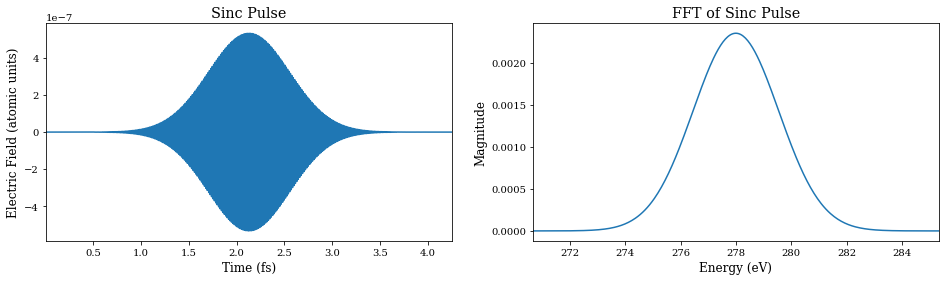

In [5]:
plt.figure(figsize=(16,4))

plt.subplot(1,2,1)
plt.plot(pulse.time*pulse.conversion_factor_au_to_as/1000, pulse.pulse, label='Carbon')
#plt.plot(pulse.time, pulse.E_max*np.exp(-(2/pulse.pulse_width)*np.abs(pulse.time - pulse.t_0)))
plt.xlabel('Time (fs)')
plt.ylabel('Electric Field (atomic units)')
plt.xlim(pulse.time_limits[0]*pulse.conversion_factor_au_to_as/1000, pulse.time_limits[1]*pulse.conversion_factor_au_to_as/1000)
plt.title('Sinc Pulse')

plt.subplot(1,2,2)
plt.plot(pulse.freq, pulse.magnitude)
plt.xlim(pulse.freq_limits)
plt.xlabel('Energy (eV)')
plt.ylabel('Magnitude')
plt.title('FFT of Sinc Pulse')

# Create Data Objects for Datasets

In [ ]:
project_dt5em3 = f"01_Ground_State/Results_METHOX_R_CORIANI_GS_CD_CAMB3LYP_CARBON/WaveT_Template{suffix}"

data_gas = Spectrum(project=project_dt5em3, color=color_gas, label=r"Our Results (Core, Solvent: None)", limits=pulse.crossings_E)

project_dt5em3 = f"03_Solvent_Experiments/Results_METHOX_R_CORIANI_CD_CAMB3LYP_CARBON_SOLV_GAS_CODiff/WaveT_Template{suffix}"

data_gas_codiff = Spectrum(project=project_dt5em3, color=color_gas, label=r"Our Results (Core, Solvent: Gas, C and O Diffuse)", limits=pulse.crossings_E)

project_dt5em3 = f"03_Solvent_Experiments/Results_METHOX_R_CORIANI_CD_CAMB3LYP_CARBON_SOLV_GAS_TZPCODiff/WaveT_Template{suffix}"

data_gas_tzpcodiff = Spectrum(project=project_dt5em3, color=color_gas, label=r"Our Results (Core, Solvent: Gas, C and O TZP Diffuse)", limits=pulse.crossings_E)


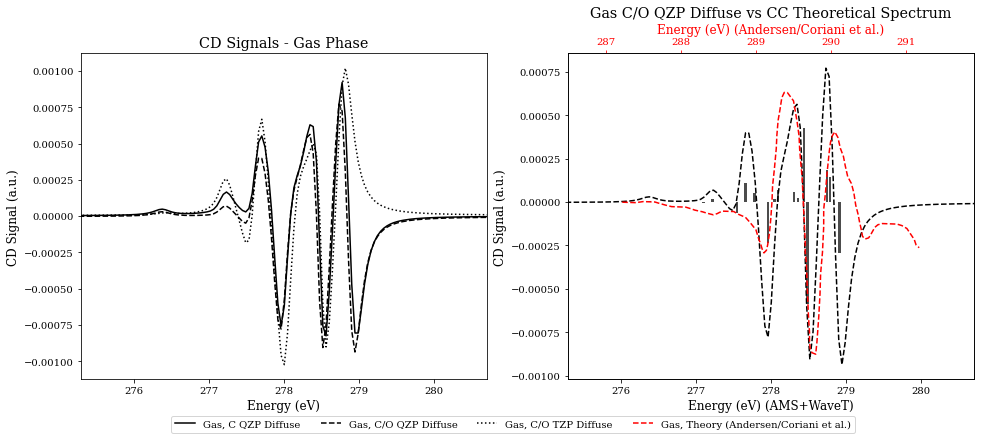

In [7]:
CC_G1_XCD_data = np.genfromtxt("/home/sanchez/Trieste_Project/Chemistry/Reference_Data/Coupled_Cluster_G1_XCD_Carbon.txt")
CC_G1_XCD_E, CC_G1_XCD_spectrum = CC_G1_XCD_data[:,0], CC_G1_XCD_data[:,1]*0.00013

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# First plot: The current plot (CD signals - Gas Phase)
axs[0].plot(data_gas.av_CD_energy_eV, data_gas.av_CD_spectrum/1, label="Gas, C QZP Diffuse", color=color_gas, linestyle="-")
axs[0].plot(data_gas_codiff.av_CD_energy_eV, data_gas_codiff.av_CD_spectrum, label="Gas, C/O QZP Diffuse", color=color_gas, linestyle="--")
axs[0].plot(data_gas_tzpcodiff.av_CD_energy_eV, data_gas_tzpcodiff.av_CD_spectrum, label="Gas, C/O TZP Diffuse", color=color_gas, linestyle=":")

axs[0].set_title("CD Signals - Gas Phase")
axs[0].set_xlabel("Energy (eV)")
axs[0].set_ylabel("CD Signal (a.u.)")
axs[0].legend()
axs[0].set_xlim(275.3,280.7)

# Create the second plot with twin x-axes for each data curve
axs[1].cla()  # clear previous plot on axs[1]

# First x-axis (bottom): data_gas_codiff
ln1, = axs[1].plot(data_gas_codiff.av_CD_energy_eV, data_gas_codiff.av_CD_spectrum,
                   label="Gas, C/O QZP Diffuse", color=color_gas, linestyle="--")
axs[1].set_xlabel("Energy (eV) (AMS+WaveT)", color=color_gas)
axs[1].tick_params(axis='x', colors=color_gas)
axs[1].bar(data_gas_codiff.root_energies, 
           data_gas_codiff.rotatory_strength*0.5, 
           color=color_gas, alpha=alpha_bar, width=bar_width)

# Create twin x-axis (top) for experimental spectrum
ax2 = axs[1].twiny()
ln2, = ax2.plot(CC_G1_XCD_E, CC_G1_XCD_spectrum, label="Gas, Theory (Andersen/Coriani et al.)",
                color="red", linestyle="--")
ax2.set_xlabel("Energy (eV) (Andersen/Coriani et al.)", color="red")
ax2.tick_params(axis='x', colors="red")

# rest of labels, title, and legend
axs[1].set_ylabel("CD Signal (a.u.)")
axs[1].set_title("Gas C/O QZP Diffuse vs CC Theoretical Spectrum")

# Combine legends from both axes
lines = [ln1, ln2]
labels = [line.get_label() for line in lines]
axs[1].legend(lines, labels, loc="best")

# Optionally set limits for both axes for comparison (if they cover the same range, else omit)
axs[1].set_xlim(275.3,280.7)
ax2.set_xlim(275.3 + 11.2,280.7 + 11.2)

# Remove the legends from individual axes, if they exist
if axs[0].legend_ is not None:
    axs[0].legend_.remove()
if axs[1].legend_ is not None:
    axs[1].legend_.remove()

# Gather all handles and labels from both axes and the twin axis
handles0, labels0 = axs[0].get_legend_handles_labels()
handles1, labels1 = axs[1].get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine unique handles/labels, preserving order
all_handles = handles0 + handles1 + handles2
all_labels = labels0 + labels1 + labels2
unique = list(dict(zip(all_labels, all_handles)).items())
final_labels = [k for k, v in unique]
final_handles = [v for k, v in unique]

# Create one legend at the bottom of the canvas spanning both axes
fig.legend(final_handles, final_labels, loc='lower center', ncol=len(final_handles), bbox_to_anchor=(0.5, -0.01))

plt.savefig("/home/sanchez/Trieste_Project/Chemistry/Reports/Report_17_03_2026/XCD_carbon_basis_set_convergence.pdf", dpi=300)

In [8]:
np.savetxt("/home/sanchez/Trieste_Project/Chemistry/Reference_Data/AMS_results/AMS_CD_carbon_basis_set_convergence_tzpcodiff.txt", np.column_stack((data_gas_tzpcodiff.av_CD_energy_eV, data_gas_tzpcodiff.av_CD_spectrum)))

np.savetxt("/home/sanchez/Trieste_Project/Chemistry/Reference_Data/AMS_results/AMS_CD_carbon_basis_set_convergence_codiff.txt", np.column_stack((data_gas_codiff.av_CD_energy_eV, data_gas_codiff.av_CD_spectrum)))


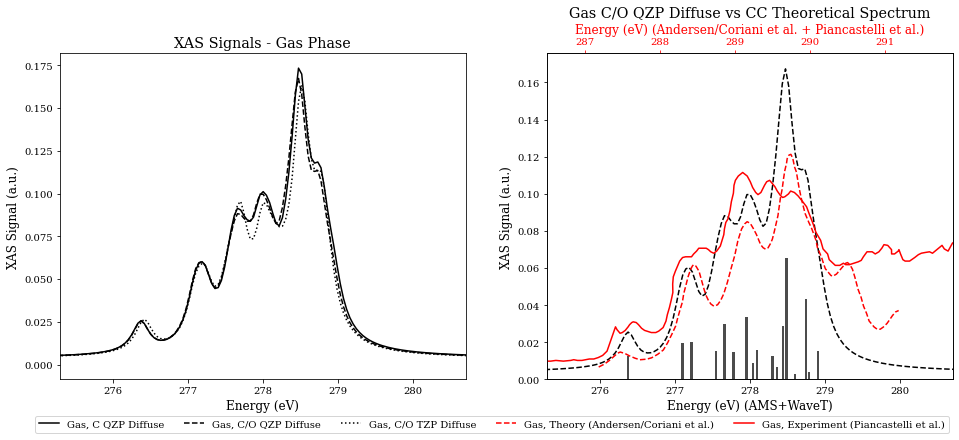

In [9]:
CC_G1_Abs_data = np.genfromtxt("/home/sanchez/Trieste_Project/Chemistry/Reference_Data/Coupled_Cluster_G1_XAS_Carbon.txt")
CC_G1_Abs_E, CC_G1_Abs_spectrum = CC_G1_Abs_data[:,0], CC_G1_Abs_data[:,1]*0.0054

Piancastelli_XAS_data_Carbon = np.genfromtxt("/home/sanchez/Trieste_Project/Chemistry/Reference_Data/Piancastelli_XAS_Carbon.txt")
Piancastelli_XAS_E_Carbon, Piancastelli_XAS_spectrum_Carbon = Piancastelli_XAS_data_Carbon[:,0], Piancastelli_XAS_data_Carbon[:,1]*0.0136

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# First plot: The current plot (CD signals - Gas Phase)
axs[0].plot(data_gas.av_lin_energy_eV, data_gas.av_lin_spectrum/1, label="Gas, C QZP Diffuse", color=color_gas, linestyle="-")
axs[0].plot(data_gas_codiff.av_lin_energy_eV, data_gas_codiff.av_lin_spectrum, label="Gas, C/O QZP Diffuse", color=color_gas, linestyle="--")
axs[0].plot(data_gas_tzpcodiff.av_lin_energy_eV, data_gas_tzpcodiff.av_lin_spectrum, label="Gas, C/O TZP Diffuse", color=color_gas, linestyle=":")

axs[0].set_title("XAS Signals - Gas Phase")
axs[0].set_xlabel("Energy (eV)")
axs[0].set_ylabel("XAS Signal (a.u.)")
axs[0].legend()
axs[0].set_xlim(275.3,280.7)

# Create the second plot with twin x-axes for each data curve
axs[1].cla()  # clear previous plot on axs[1]

# First x-axis (bottom): data_gas_codiff
ln1, = axs[1].plot(data_gas_codiff.av_lin_energy_eV, data_gas_codiff.av_lin_spectrum,
                   label="Gas, C/O QZP Diffuse", color=color_gas, linestyle="--")
axs[1].set_xlabel("Energy (eV) (AMS+WaveT)", color=color_gas)
axs[1].tick_params(axis='x', colors=color_gas)
axs[1].bar(data_gas_codiff.root_energies, 
           data_gas_codiff.oscillatory_strength*20, 
           color=color_gas, alpha=alpha_bar, width=bar_width)

# Create twin x-axis (top) for experimental spectrum
ax2 = axs[1].twiny()
ln2, = ax2.plot(CC_G1_Abs_E, CC_G1_Abs_spectrum, label="Gas, Theory (Andersen/Coriani et al.)",
                color="red", linestyle="--")
ln3, = ax2.plot(Piancastelli_XAS_E_Carbon, Piancastelli_XAS_spectrum_Carbon, label="Gas, Experiment (Piancastelli et al.)",
                color="red", linestyle="-")
ax2.set_xlabel("Energy (eV) (Andersen/Coriani et al. + Piancastelli et al.)", color="red")
ax2.tick_params(axis='x', colors="red")

# rest of labels, title, and legend
axs[1].set_ylabel("XAS Signal (a.u.)")
axs[1].set_title("Gas C/O QZP Diffuse vs CC Theoretical Spectrum")

# Combine legends from both axes
lines = [ln1, ln2, ln3]
labels = [line.get_label() for line in lines]
axs[1].legend(lines, labels, loc="best")

# Optionally set limits for both axes for comparison (if they cover the same range, else omit)
axs[1].set_xlim(275.3,280.7)
ax2.set_xlim(275.3 + 11.2,280.7 + 11.2)

# Remove the legends from individual axes, if they exist
if axs[0].legend_ is not None:
    axs[0].legend_.remove()
if axs[1].legend_ is not None:
    axs[1].legend_.remove()

# Gather all handles and labels from both axes and the twin axis
handles0, labels0 = axs[0].get_legend_handles_labels()
handles1, labels1 = axs[1].get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine unique handles/labels, preserving order
all_handles = handles0 + handles1 + handles2
all_labels = labels0 + labels1 + labels2
unique = list(dict(zip(all_labels, all_handles)).items())
final_labels = [k for k, v in unique]
final_handles = [v for k, v in unique]

# Create one legend at the bottom of the canvas spanning both axes
fig.legend(final_handles, final_labels, loc='lower center', ncol=len(final_handles), bbox_to_anchor=(0.5, -0.01))

plt.savefig("/home/sanchez/Trieste_Project/Chemistry/Reports/Report_17_03_2026/XAS_carbon_basis_set_convergence.pdf", dpi=300)

In [10]:
project_dt5em3 = f"03_Solvent_Experiments/Results_METHOX_R_CORIANI_CD_CAMB3LYP_CARBON_SOLV_GAS_CODiff_GEOM_SHIFT/WaveT_Template{suffix}"

data_gas_codiff_shift = Spectrum(project=project_dt5em3, color=color_gas, label=r"Our Results (Core, Solvent: Gas, C and O TZP Diffuse, Geom. Shift)", limits=pulse.crossings_E)

project_dt5em3 = f"03_Solvent_Experiments/Results_METHOX_R_CORIANI_CD_CAMB3LYP_CARBON_SOLV_GAS_CODiff_GEOM_ROT/WaveT_Template{suffix}"

data_gas_codiff_rot = Spectrum(project=project_dt5em3, color=color_gas, label=r"Our Results (Core, Solvent: Gas, C and O TZP Diffuse, Geom. Rotated)", limits=pulse.crossings_E)

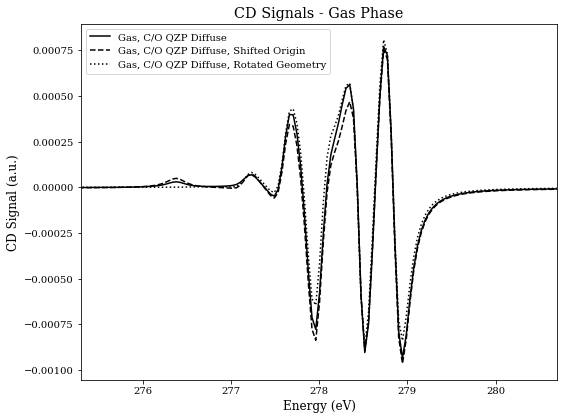

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))


ax.plot(data_gas_codiff.av_CD_energy_eV, data_gas_codiff.av_CD_spectrum, label="Gas, C/O QZP Diffuse", color=color_gas, linestyle="-")
ax.plot(data_gas_codiff_shift.av_CD_energy_eV, data_gas_codiff_shift.av_CD_spectrum, label="Gas, C/O QZP Diffuse, Shifted Origin", color=color_gas, linestyle="--")
ax.plot(data_gas_codiff_rot.av_CD_energy_eV, data_gas_codiff_rot.av_CD_spectrum, label="Gas, C/O QZP Diffuse, Rotated Geometry", color=color_gas, linestyle=":")

ax.set_title("CD Signals - Gas Phase")
ax.set_xlabel("Energy (eV)")
ax.set_ylabel("CD Signal (a.u.)")
ax.legend()
ax.set_xlim(275.3,280.7)

plt.tight_layout()
plt.show()

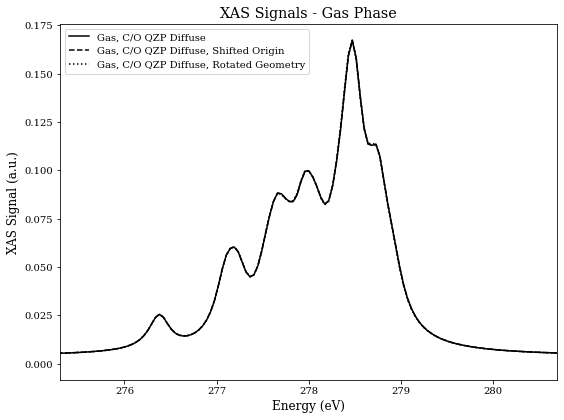

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))


ax.plot(data_gas_codiff.av_lin_energy_eV, data_gas_codiff.av_lin_spectrum, label="Gas, C/O QZP Diffuse", color=color_gas, linestyle="-")
ax.plot(data_gas_codiff_shift.av_lin_energy_eV, data_gas_codiff_shift.av_lin_spectrum, label="Gas, C/O QZP Diffuse, Shifted Origin", color=color_gas, linestyle="--")
ax.plot(data_gas_codiff_rot.av_lin_energy_eV, data_gas_codiff_rot.av_lin_spectrum, label="Gas, C/O QZP Diffuse, Rotated Geometry", color=color_gas, linestyle=":")

ax.set_title("XAS Signals - Gas Phase")
ax.set_xlabel("Energy (eV)")
ax.set_ylabel("XAS Signal (a.u.)")
ax.legend()
ax.set_xlim(275.3,280.7)

plt.tight_layout()
plt.show()

In [13]:
project_dt5em3 = f"03_Solvent_Experiments/Results_METHOX_R_CORIANI_CD_CAMB3LYP_CARBON_SOLV_WATER_CODiff/WaveT_Template{suffix}"

data_water_codiff = Spectrum(project=project_dt5em3, color=color_water, label=r"Our Results (Core, Solvent: Water, C and O Diffuse)", limits=pulse.crossings_E)

project_dt5em3 = f"03_Solvent_Experiments/Results_METHOX_R_CORIANI_CD_CAMB3LYP_CARBON_SOLV_BENZENE_CODiff/WaveT_Template{suffix}"

data_benzene_codiff = Spectrum(project=project_dt5em3, color=color_benzene, label=r"Our Results (Core, Solvent: Benzene, C and O Diffuse)", limits=pulse.crossings_E)

project_dt5em3 = f"03_Solvent_Experiments/Results_METHOX_R_CORIANI_CD_CAMB3LYP_CARBON_SOLV_HEXANE_CODiff/WaveT_Template{suffix}"

data_hexane_codiff = Spectrum(project=project_dt5em3, color=color_hexane, label=r"Our Results (Core, Solvent: Hexane, C and O Diffuse)", limits=pulse.crossings_E)

project_dt5em3 = f"03_Solvent_Experiments/Results_METHOX_R_CORIANI_CD_CAMB3LYP_CARBON_SOLV_METHANOL_CODiff/WaveT_Template{suffix}"

data_methanol_codiff = Spectrum(project=project_dt5em3, color=color_methanol, label=r"Our Results (Core, Solvent: Methanol, C and O Diffuse)", limits=pulse.crossings_E)

project_dt5em3 = f"03_Solvent_Experiments/Results_METHOX_R_CORIANI_CD_CAMB3LYP_CARBON_SOLV_GAS_CODiff/WaveT_Template{suffix}"

data_gas_codiff = Spectrum(project=project_dt5em3, color=color_gas, label=r"Our Results (Core, Solvent: Gas, C and O Diffuse)", limits=pulse.crossings_E)

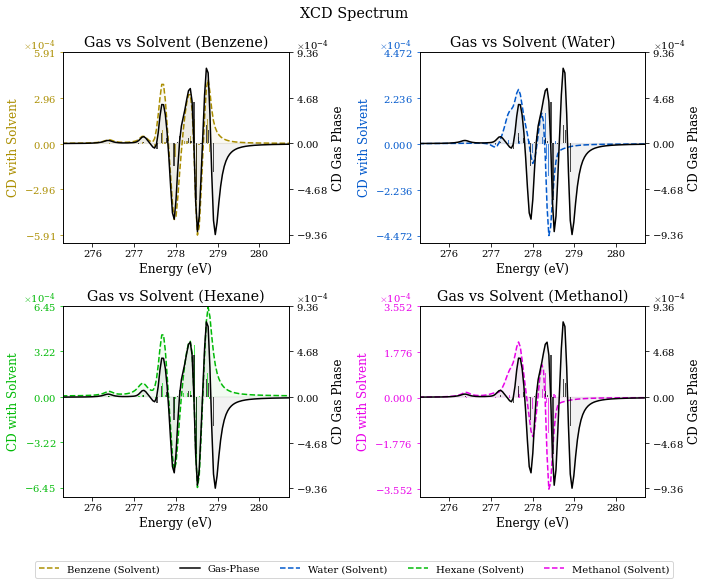

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
fig.patch.set_facecolor("white")
axs = axs.flatten()
plt.suptitle("XCD Spectrum")


# --- función para dibujar gas + solvent ---
def plot_pair(ax, data_solvent, data_gas, label, color_solvent, color_solvent_bar):

    # ===== eje izquierdo → solvent =====
    l1, = ax.plot(
        data_solvent.av_CD_energy_eV,
        data_solvent.av_CD_spectrum,
        color=color_solvent,
        label=label,
        linestyle="--"
    )

    ax.fill_between(
        data_solvent.av_CD_energy_eV,
        0,
        data_solvent.av_CD_spectrum,
        color=color_solvent,
        alpha=alpha_area
    )

    ax.bar(
        data_solvent.root_energies,
        data_solvent.rotatory_strength * 0.5,
        color=color_solvent_bar,
        alpha=alpha_bar,
        width=bar_width
    )

    ax.set_ylabel("CD with Solvent", color=color_solvent)
    ax.tick_params(axis='y', colors=color_solvent)

    # ===== eje derecho → gas =====
    ax2 = ax.twinx()

    l2, = ax2.plot(
        data_gas.av_CD_energy_eV,
        data_gas.av_CD_spectrum,
        color=color_gas,
        label="Gas-Phase"
    )

    ax2.fill_between(
        data_gas.av_CD_energy_eV,
        0,
        data_gas.av_CD_spectrum,
        color=color_gas,
        alpha=alpha_area
    )

    ax2.bar(
        data_gas.root_energies,
        data_gas.rotatory_strength * 0.5,
        color=color_gas_bar,
        alpha=alpha_bar,
        width=bar_width
    )

    ax2.set_ylabel("CD Gas Phase")

    ax.set_xlim(275.3,280.7)
    #ax.set_xlim(pulse.crossings_E[0], pulse.crossings_E[1])
    ax.set_xlabel("Energy (eV)")

    max_solvent = max(abs(data_solvent.av_CD_spectrum.min()), abs(data_solvent.av_CD_spectrum.max()))
    max_gas = max(abs(data_gas.av_CD_spectrum.min()), abs(data_gas.av_CD_spectrum.max()))

    #ax.set_ylim(-1.1*max_solvent, 1.1*max_solvent)
    #ax2.set_ylim(-1.1*max_gas, 1.1*max_gas)
    y_ticks_solvent = yticks_with_zero(data_solvent.av_CD_spectrum, 5)
    y_ticks_gas = yticks_with_zero(data_gas.av_CD_spectrum, 5)
    ax.set_yticks(y_ticks_solvent)
    ax2.set_yticks(y_ticks_gas)
    ax.set_ylim(ymax=1*(y_ticks_solvent[-1] - y_ticks_solvent[-2]) + y_ticks_solvent[-2])
    ax2.set_ylim(ymax=1*(y_ticks_gas[-1] - y_ticks_gas[-2]) + y_ticks_gas[-2])

    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0,0))
    ax.yaxis.get_offset_text().set_x(-0.18)   # eje izquierdo → más a la izquierda
    ax2.yaxis.get_offset_text().set_x(1.18)   # eje derecho → más a la derecha

    ax.yaxis.set_major_formatter(formatter)
    ax2.yaxis.set_major_formatter(formatter)


    return [l1, l2], [label, "Gas-Phase"]


# --- ORDEN: gas+benzene, gas+water, gas+hexane, gas+methanol ---
pairs = [
    (data_benzene_codiff, color_benzene, color_benzene_bar, "Gas vs Solvent (Benzene)", "Benzene (Solvent)"),
    (data_water_codiff, color_water, color_water_bar, "Gas vs Solvent (Water)", "Water (Solvent)"),
    (data_hexane_codiff, color_hexane, color_hexane_bar, "Gas vs Solvent (Hexane)", "Hexane (Solvent)"),
    (data_methanol_codiff, color_methanol, color_methanol_bar, "Gas vs Solvent (Methanol)", "Methanol (Solvent)"),
]

# --- acumular TODOS los handles para leyenda global ---
handles = []
labels = []

for ax, (data_solvent, c, cbar, title, label) in zip(axs, pairs):
    h, l = plot_pair(ax, data_solvent, data_gas_codiff, label, c, cbar)
    ax.set_title(title)

    handles.extend(h)
    labels.extend(l)

# --- eliminar duplicados (gas solo aparece una vez) ---
by_label = OrderedDict(zip(labels, handles))

# --- LEYENDA GLOBAL ABAJO CENTRADA ---
fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="lower center",
    ncol=5,
    bbox_to_anchor=(0.5, -0.02),
    frameon=True
)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # espacio para leyenda
plt.savefig("/home/sanchez/Trieste_Project/Chemistry/Reports/Report_17_03_2026/XCD_Carbon_Solvents_COSMO_CODiffuse.pdf", dpi=300)

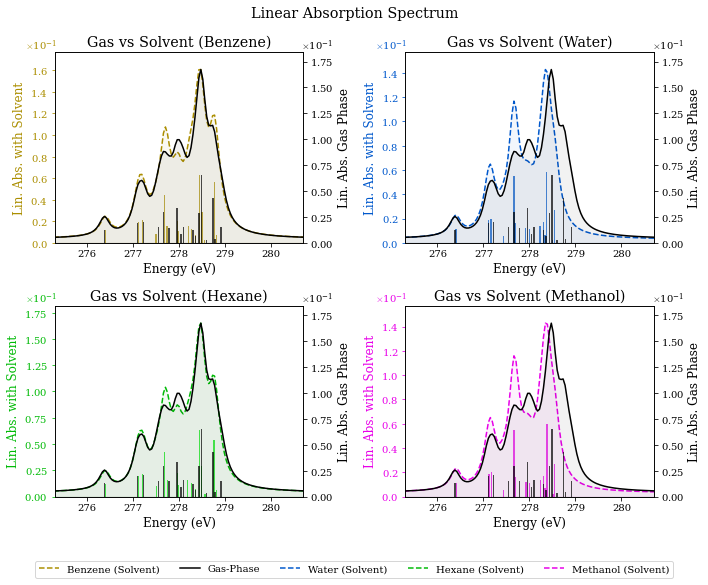

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
fig.patch.set_facecolor("white")
axs = axs.flatten()
plt.suptitle("Linear Absorption Spectrum")


# --- función para dibujar gas + solvent ---
def plot_pair(ax, data_solvent, data_gas, label, color_solvent, color_solvent_bar):

    # ===== eje izquierdo → solvent =====
    l1, = ax.plot(
        data_solvent.av_lin_energy_eV,
        data_solvent.av_lin_spectrum,
        color=color_solvent,
        label=label,
        linestyle="--"
    )

    ax.fill_between(
        data_solvent.av_lin_energy_eV,
        0,
        data_solvent.av_lin_spectrum,
        color=color_solvent,
        alpha=alpha_area
    )

    ax.bar(
        data_solvent.root_energies,
        data_solvent.oscillatory_strength * 20,
        color=color_solvent_bar,
        alpha=alpha_bar,
        width=bar_width
    )

    ax.set_ylabel("Lin. Abs. with Solvent", color=color_solvent)
    ax.tick_params(axis='y', colors=color_solvent)

    # ===== eje derecho → gas =====
    ax2 = ax.twinx()

    l2, = ax2.plot(
        data_gas.av_lin_energy_eV,
        data_gas.av_lin_spectrum,
        color=color_gas,
        label="Gas-Phase"
    )

    ax2.fill_between(
        data_gas.av_lin_energy_eV,
        0,
        data_gas.av_lin_spectrum,
        color=color_gas,
        alpha=alpha_area
    )

    ax2.bar(
        data_gas.root_energies,
        data_gas.oscillatory_strength * 20,
        color=color_gas_bar,
        alpha=alpha_bar,
        width=bar_width
    )

    ax2.set_ylabel("Lin. Abs. Gas Phase")

    ax.set_xlim(275.3,280.7)
    #ax.set_xlim(pulse.crossings_E[0], pulse.crossings_E[1])
    ax.set_xlabel("Energy (eV)")

    max_solvent = max(abs(data_solvent.av_lin_spectrum.min()), abs(data_solvent.av_lin_spectrum.max()))
    max_gas = max(abs(data_gas.av_lin_spectrum.min()), abs(data_gas.av_lin_spectrum.max()))

    ax.set_ylim(0, 1.1*max_solvent)
    ax2.set_ylim(0, 1.1*max_gas)

    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0,0))
    ax.yaxis.set_major_formatter(formatter)
    ax2.yaxis.set_major_formatter(formatter)
    ax.yaxis.get_offset_text().set_x(-0.12)   # eje izquierdo → más a la izquierda
    ax2.yaxis.get_offset_text().set_x(1.12)   # eje derecho → más a la derecha

    return [l1, l2], [label, "Gas-Phase"]


# --- ORDEN: gas+benzene, gas+water, gas+hexane, gas+methanol ---
pairs = [
    (data_benzene_codiff, color_benzene, color_benzene_bar, "Gas vs Solvent (Benzene)", "Benzene (Solvent)"),
    (data_water_codiff, color_water, color_water_bar, "Gas vs Solvent (Water)", "Water (Solvent)"),
    (data_hexane_codiff, color_hexane, color_hexane_bar, "Gas vs Solvent (Hexane)", "Hexane (Solvent)"),
    (data_methanol_codiff, color_methanol, color_methanol_bar, "Gas vs Solvent (Methanol)", "Methanol (Solvent)"),
]

# --- acumular TODOS los handles para leyenda global ---
handles = []
labels = []

for ax, (data_solvent, c, cbar, title, label) in zip(axs, pairs):
    h, l = plot_pair(ax, data_solvent, data_gas_codiff, label, c, cbar)
    ax.set_title(title)

    handles.extend(h)
    labels.extend(l)

# --- eliminar duplicados (gas solo aparece una vez) ---
by_label = OrderedDict(zip(labels, handles))

# --- LEYENDA GLOBAL ABAJO CENTRADA ---
fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="lower center",
    ncol=5,
    bbox_to_anchor=(0.5, -0.02),
    frameon=True
)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # espacio para leyenda
plt.savefig("/home/sanchez/Trieste_Project/Chemistry/Reports/Report_17_03_2026/XAS_Carbon_Solvents_COSMO_CODiffuse.pdf", dpi=300)